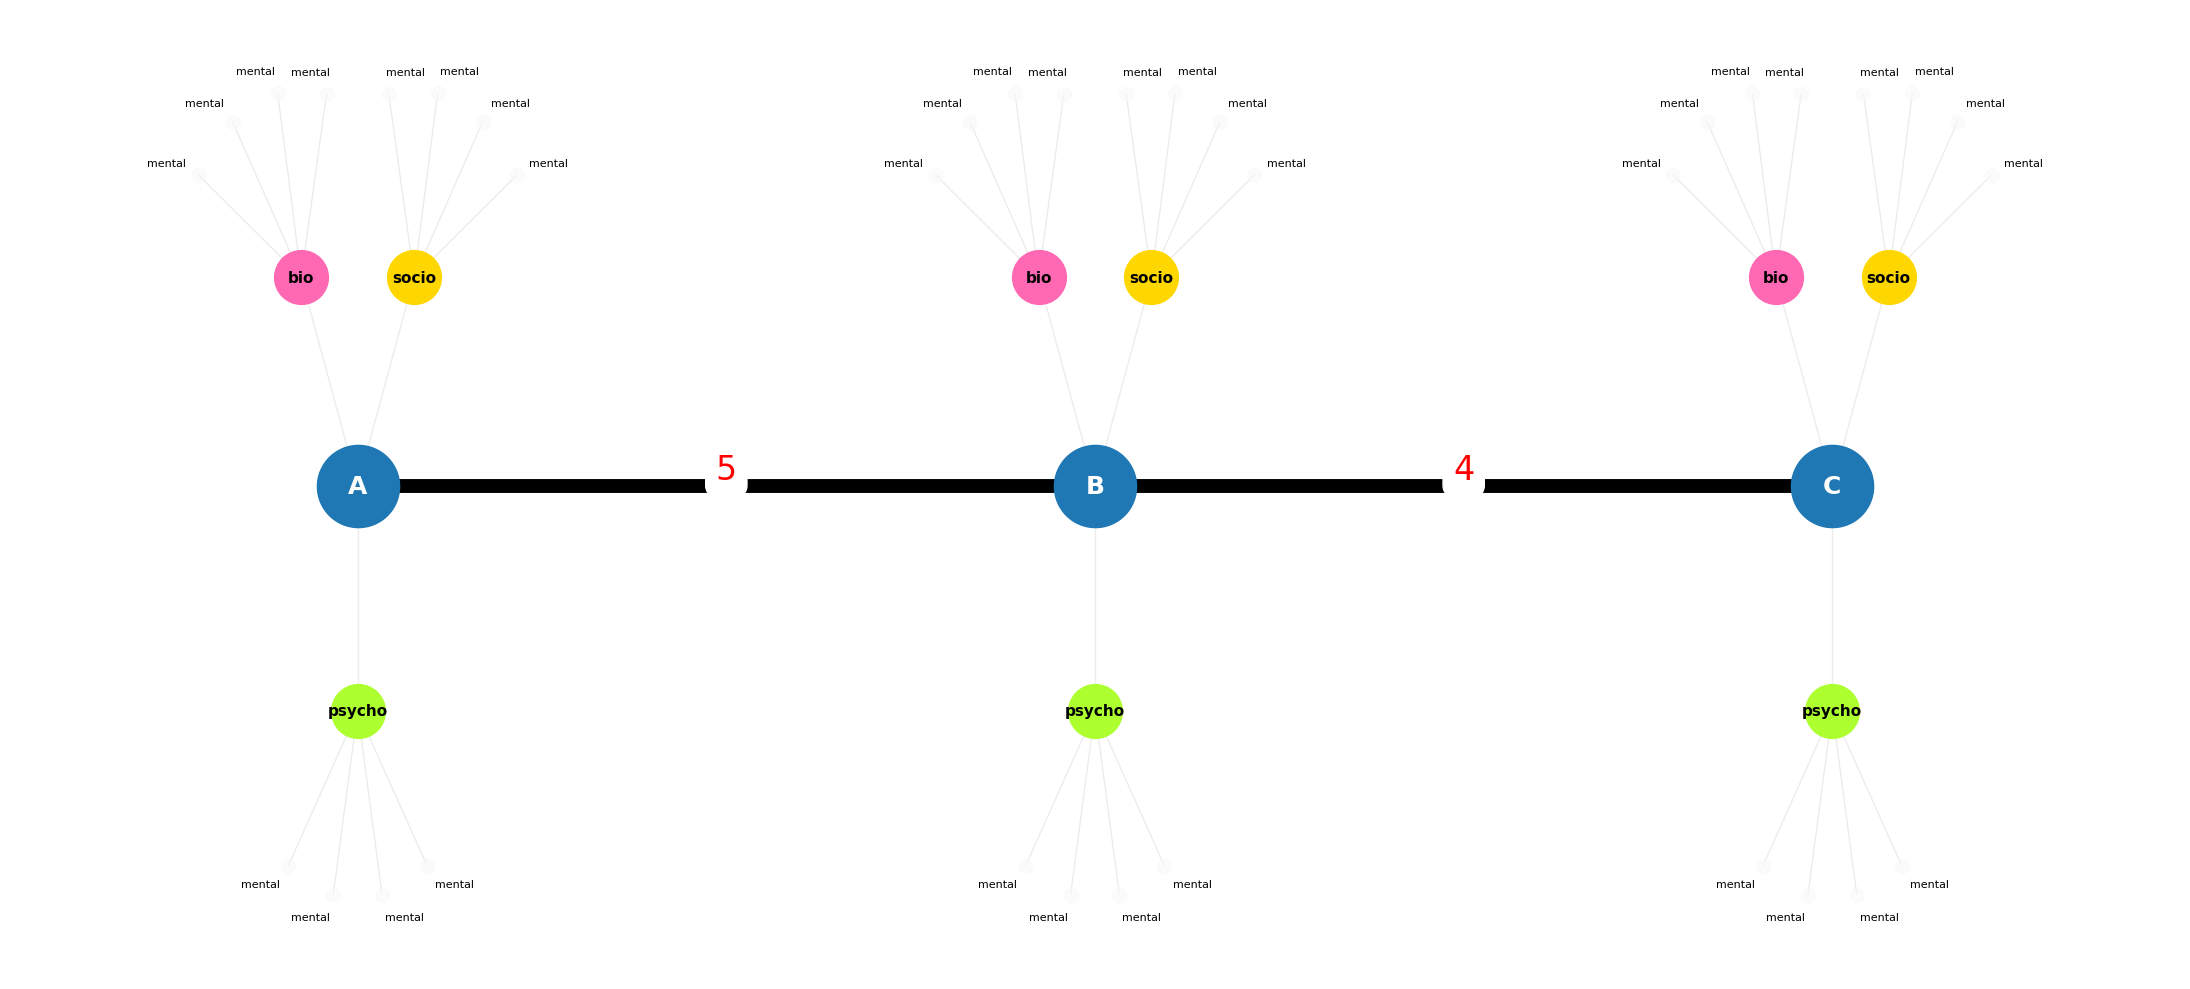

In [ ]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def generate_clean_description_graph(edge_strings, node_attributes):
    G = nx.Graph()
    pattern = r"(\w+)\s*[- ]*\s*(\d+)\s*[- ]*>\s*(\w+)"
    main_nodes_ordered = []
    
    for s in edge_strings:
        match = re.search(pattern, s)
        if match:
            u, w, v = match.groups()
            G.add_edge(u, v, weight=int(w), edge_type="main")
            for node in [u, v]:
                if node not in main_nodes_ordered: main_nodes_ordered.append(node)

    key_colors = {"socio": "#FFD700", "psycho": "#ADFF2F", "bio": "#FF69B4"}
    pos = {}
    label_pos = {} # Separate dictionary for text placement
    
    main_nodes, key_nodes, val_nodes = [], [], []
    main_labels, key_labels, val_labels = {}, {}, {}
    node_color_map = {}

    for idx, main_node in enumerate(main_nodes_ordered):
        base_x, base_y = idx * 15, 0 # Increased spacing between A, B, C
        pos[main_node] = np.array([base_x, base_y])
        main_nodes.append(main_node)
        main_labels[main_node] = main_node
        
        attrs = node_attributes.get(main_node, {})
        attr_keys = list(attrs.keys())
        
        for j, key in enumerate(attr_keys):
            # Define specific sectors: Bio (Top Left), Socio (Top Right), Psycho (Bottom)
            if key == "bio": angle = 2.5 * np.pi / 4 # ~112 degrees
            elif key == "socio": angle = 1.5 * np.pi / 4 # ~67 degrees
            else: angle = -np.pi / 2 # Bottom
            
            kx, ky = base_x + 3.0 * np.cos(angle), base_y + 3.0 * np.sin(angle)
            key_id = f"{main_node}_{key}"
            pos[key_id] = np.array([kx, ky])
            key_nodes.append(key_id)
            key_labels[key_id] = key
            node_color_map[key_id] = key_colors.get(key, "gray")
            G.add_edge(main_node, key_id, edge_type="attr")
            
            vals = attrs[key]
            for k, val in enumerate(vals):
                # Spread out long descriptions in a wider fan
                v_angle = angle + (k - (len(vals)-1)/2) * 0.4
                vx, vy = kx + 2.5 * np.cos(v_angle), ky + 2.5 * np.sin(v_angle)
                val_id = f"{key_id}_v{k}"
                pos[val_id] = np.array([vx, vy])
                
                # OFFSET LABEL: Put text slightly further than the node
                label_pos[val_id] = np.array([vx + 0.3 * np.cos(v_angle), vy + 0.3 * np.sin(v_angle)])
                
                val_nodes.append(val_id)
                val_labels[val_id] = str(val)
                G.add_edge(key_id, val_id, edge_type="val")

    # 3. DRAWING
    plt.figure(figsize=(22, 10))
    
    # Draw Edges
    main_e = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'main']
    other_e = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') != 'main']
    nx.draw_networkx_edges(G, pos, edgelist=main_e, width=10, edge_color="black")
    nx.draw_networkx_edges(G, pos, edgelist=other_e, width=1, edge_color="gray", alpha=0.15)

    # Main Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=main_nodes, node_color="#1f78b4", node_size=3500)
    nx.draw_networkx_labels(G, pos, labels=main_labels, font_color="white", font_weight="bold", font_size=18)

    # Key Nodes
    for knode in key_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=[knode], node_color=node_color_map[knode], node_size=1500)
    nx.draw_networkx_labels(G, pos, labels=key_labels, font_size=11, font_weight="bold")

    # Value Nodes (Small circles, text is offset)
    nx.draw_networkx_nodes(G, pos, nodelist=val_nodes, node_color="#f9f9f9", node_size=100, alpha=0.5)
    
    # Draw OFFSET labels with smart alignment
    for vid, text in val_labels.items():
        x, y = label_pos[vid]
        # Wrap long text if needed
        clean_text = text.replace(" ", "\n") if len(text) > 20 else text
        
        # Align left/right based on which side of the parent it's on
        ha = 'left' if x > pos[vid.split('_')[0]][0] else 'right'
        plt.text(x, y, clean_text, fontsize=8, ha=ha, va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    # Weights
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True) if 'weight' in d}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=24, font_color="red", verticalalignment='bottom')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- INPUT WITH LONG STRINGS ---
edge_data = ["A -- 5 -- > B", "B --- 4 ---> C"]
long_desc = "mental"

attr_data = {
    "A": {"socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
    "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
    "bio": [long_desc, long_desc, long_desc, long_desc]},
    "B": "socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
    "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
    "bio": [long_desc, long_desc, long_desc, long_desc]},
    "C": "socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
    "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
    "bio": [long_desc, long_desc, long_desc, long_desc]}
}

generate_clean_description_graph(edge_data, attr_data)


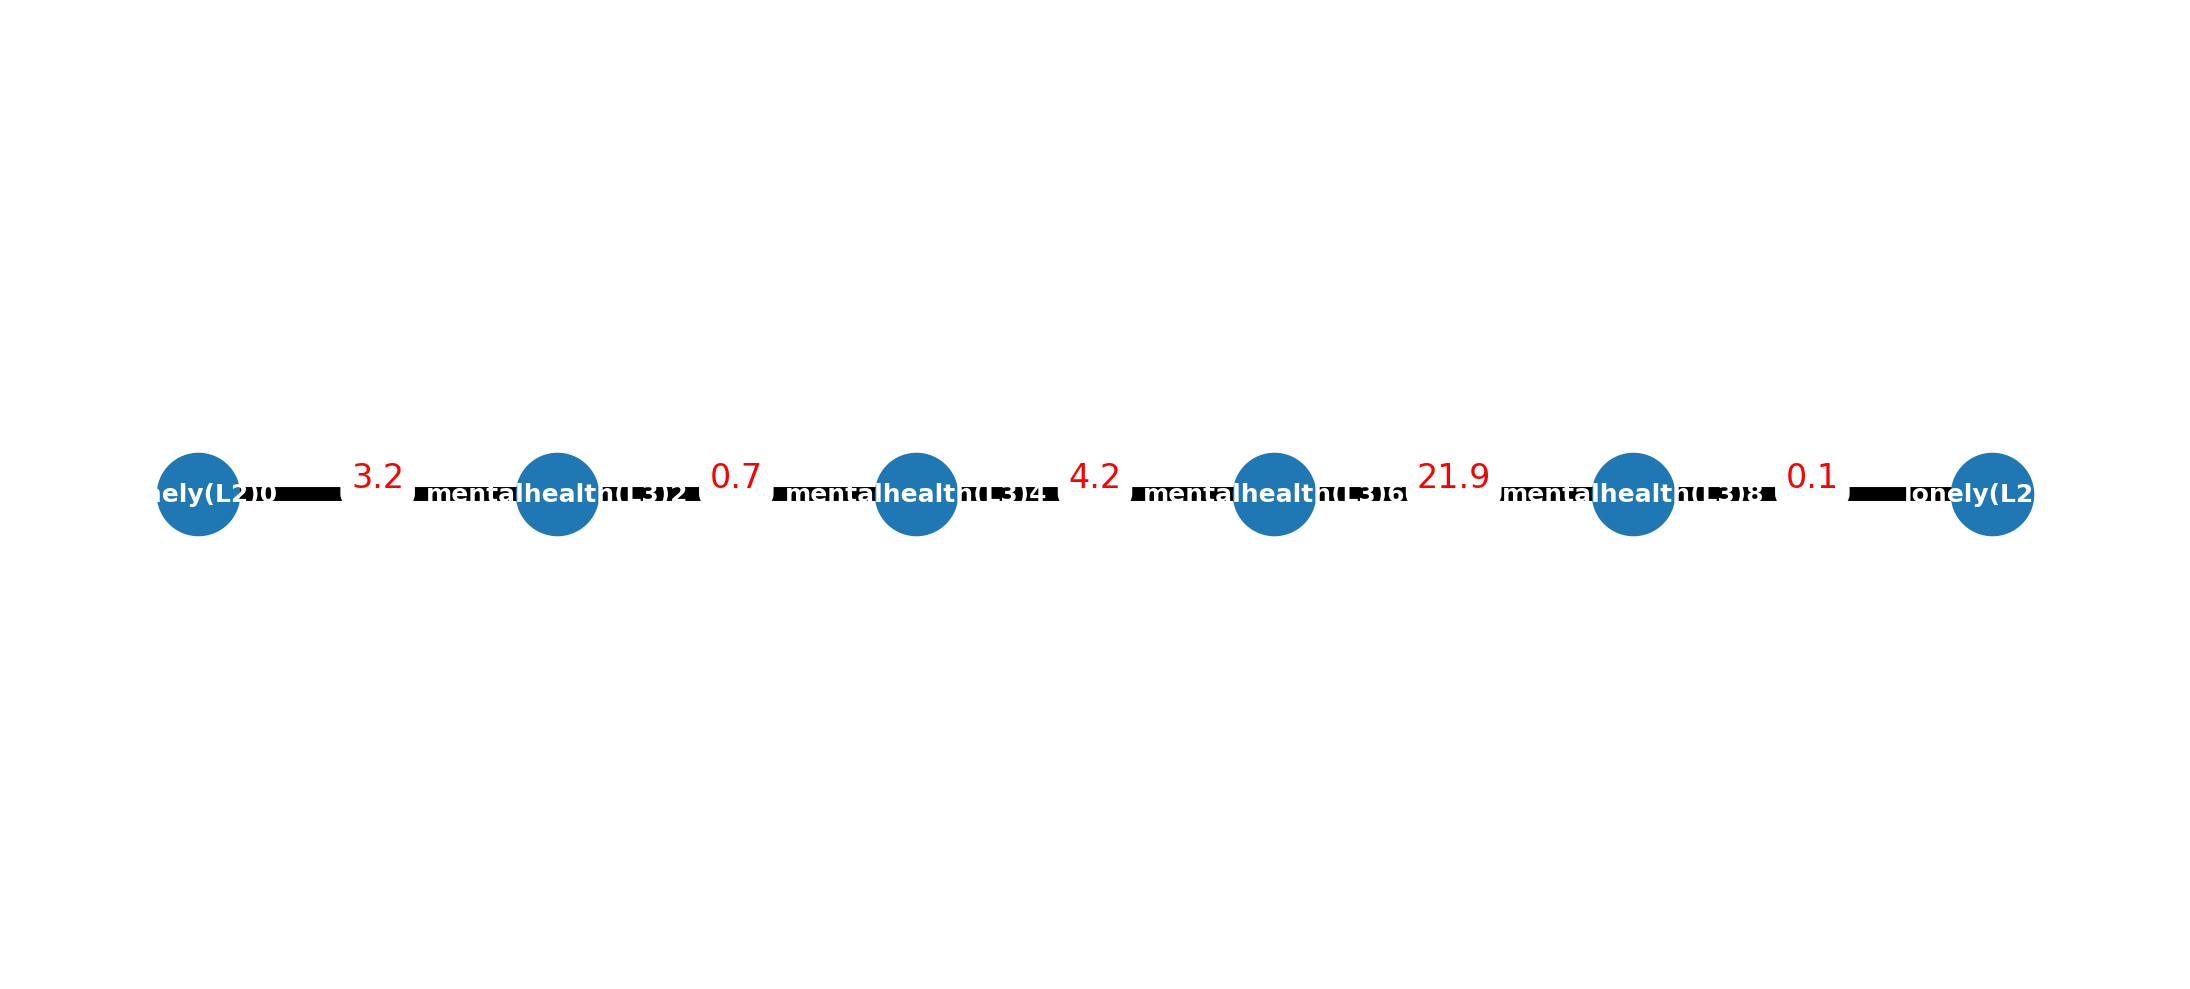

In [24]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def create_groups(clinical_trajectory):
    sample_flow_l = clinical_trajectory.split("--")
    
    for idx, v in enumerate(sample_flow_l):
        v = v.replace(">", "").strip() if '>' in v else v.strip()
        if "d)" in v:
            v = v.replace("(", "").replace("d)", "").strip()
            v = float(v)
        sample_flow_l[idx] = v

    groups = []
    for i in range(0, len(sample_flow_l), 2):
        if i + 2 < len(sample_flow_l): 
            groups.append((sample_flow_l[i]+str(i), sample_flow_l[i + 1], sample_flow_l[i + 2]+str(i+2)))
    
    main_nodes_ordered = [v+str(idx) for idx, v in enumerate(sample_flow_l) if isinstance(v, str)]

    return groups, main_nodes_ordered

def generate_clean_description_graph(edge_strings, node_attributes):
    G = nx.Graph()
    main_nodes_ordered = []
    
    groups, main_nodes_ordered = create_groups(edge_strings)
    for grp in groups:
        u, w, v = grp
        G.add_edge(u, v, weight=w, edge_type="main")

    key_colors = {"socio": "#FFD700", "psycho": "#ADFF2F", "bio": "#FF69B4"}
    pos = {}
    label_pos = {} # Separate dictionary for text placement
    
    main_nodes, key_nodes, val_nodes = [], [], []
    main_labels, key_labels, val_labels = {}, {}, {}
    node_color_map = {}

    breakpoint()
    for idx, main_node in enumerate(main_nodes_ordered):
        base_x, base_y = idx * 15, 0 # Increased spacing between A, B, C
        pos[main_node] = np.array([base_x, base_y])
        main_nodes.append(main_node)
        main_labels[main_node] = main_node
        
        attrs = node_attributes.get(main_node, {})
        attr_keys = list(attrs.keys())
        
        for j, key in enumerate(attr_keys):
            # Define specific sectors: Bio (Top Left), Socio (Top Right), Psycho (Bottom)
            if key == "bio": angle = 2.5 * np.pi / 4 # ~112 degrees
            elif key == "socio": angle = 1.5 * np.pi / 4 # ~67 degrees
            else: angle = -np.pi / 2 # Bottom
            
            kx, ky = base_x + 3.0 * np.cos(angle), base_y + 3.0 * np.sin(angle)
            key_id = f"{main_node}_{key}"
            pos[key_id] = np.array([kx, ky])
            key_nodes.append(key_id)
            key_labels[key_id] = key
            node_color_map[key_id] = key_colors.get(key, "gray")
            G.add_edge(main_node, key_id, edge_type="attr")
            
            vals = attrs[key]
            for k, val in enumerate(vals):
                # Spread out long descriptions in a wider fan
                v_angle = angle + (k - (len(vals)-1)/2) * 0.4
                vx, vy = kx + 2.5 * np.cos(v_angle), ky + 2.5 * np.sin(v_angle)
                val_id = f"{key_id}_v{k}"
                pos[val_id] = np.array([vx, vy])
                
                # OFFSET LABEL: Put text slightly further than the node
                label_pos[val_id] = np.array([vx + 0.3 * np.cos(v_angle), vy + 0.3 * np.sin(v_angle)])
                
                val_nodes.append(val_id)
                val_labels[val_id] = str(val)
                G.add_edge(key_id, val_id, edge_type="val")

    # 3. DRAWING
    plt.figure(figsize=(22, 10))
    
    # Draw Edges
    main_e = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'main']
    other_e = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') != 'main']
    nx.draw_networkx_edges(G, pos, edgelist=main_e, width=10, edge_color="black")
    nx.draw_networkx_edges(G, pos, edgelist=other_e, width=1, edge_color="gray", alpha=0.15)

    # Main Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=main_nodes, node_color="#1f78b4", node_size=3500)
    nx.draw_networkx_labels(G, pos, labels=main_labels, font_color="white", font_weight="bold", font_size=18)

    # Key Nodes
    for knode in key_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=[knode], node_color=node_color_map[knode], node_size=1500)
    nx.draw_networkx_labels(G, pos, labels=key_labels, font_size=11, font_weight="bold")

    # Value Nodes (Small circles, text is offset)
    nx.draw_networkx_nodes(G, pos, nodelist=val_nodes, node_color="#f9f9f9", node_size=100, alpha=0.5)
    
    # Draw OFFSET labels with smart alignment
    for vid, text in val_labels.items():
        x, y = label_pos[vid]
        # Wrap long text if needed
        clean_text = text.replace(" ", "\n") if len(text) > 20 else text
        
        # Align left/right based on which side of the parent it's on
        ha = 'left' if x > pos[vid.split('_')[0]][0] else 'right'
        plt.text(x, y, clean_text, fontsize=8, ha=ha, va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    # Weights
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True) if 'weight' in d}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=24, font_color="red", verticalalignment='bottom')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- INPUT WITH LONG STRINGS ---
edge_data = 'lonely(L2) --(3.2d)--> mentalhealth(L3) --(0.7d)--> mentalhealth(L3) --(4.2d)--> mentalhealth(L3) --(21.9d)--> mentalhealth(L3) --(0.1d)--> lonely(L2)'
long_desc = "mental"

attr_data = {
    "A": {
        "socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
        "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
        "bio": [long_desc, long_desc, long_desc, long_desc]
    },
    "B": { 
        "socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
        "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
        "bio": [long_desc, long_desc, long_desc, long_desc]
    },
    "C": {
        "socio": [long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc, long_desc], 
        "psycho": [long_desc, long_desc, long_desc, long_desc,long_desc, long_desc, long_desc, long_desc], 
        "bio": [long_desc, long_desc, long_desc, long_desc]
    }
}

generate_clean_description_graph(edge_data, attr_data)